Exercise - Analyzing Data Science Job Demand

In [1]:
import pandas as pd, matplotlib.pyplot as plt
from datasets import load_dataset, Dataset

# Loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()  # Changed: 'to pandas' to 'to_pandas()'

# Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

c:\Users\Greg\anaconda3\envs\Python_Data_Project_1_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# I am trying to select a country other than the United States, maybe 2nd or 3rd in job postings
# Let us settle on Russia
country_avg_salary = df.pivot_table(
    values='salary_year_avg',
    index='job_country',
    aggfunc='mean'
).sort_values('salary_year_avg', ascending=False).head(5)
country_avg_salary

,salary_year_avg
job_country,
Belarus,400000.000000
Russia,292500.000000
Bahamas,201511.619048
Dominican Republic,157500.000000
Northern Mariana Islands,155485.500000


In [9]:
#First step is we're only going to look at roles in the Russia. 
# So we're going to create a copy of our DataFrame and only include roles that are in Russia.

## Skill count per month for data analysts
df_ru = df[df['job_country'] == 'Russia'].copy()
df_ru.sample(10)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
408625,Data Engineer,Data Engineer,"Moscow, Russia",via BeBee,Full-time,False,Russia,2023-07-26 16:43:36,False,False,Russia,NaN,NaN,NaN,Mail Group,"['hadoop', 'spark']","{'libraries': ['hadoop', 'spark']}"
262849,Data Scientist,Data инженер,"Moscow, Russia",via hh.ru,Full-time,False,Russia,2023-01-24 07:51:15,True,False,Russia,NaN,NaN,NaN,QIWI,"['python', 'scala', 'java', 'sql', 'cassandra'...","{'cloud': ['oracle'], 'databases': ['cassandra..."
58896,Data Engineer,DWH/Data Инженер,"Moscow, Russia",via hh.ru,Full-time,False,Russia,2023-11-01 06:37:34,True,False,Russia,NaN,NaN,NaN,Кредитит,"['sql', 'python', 'airflow', 'confluence']","{'async': ['confluence'], 'libraries': ['airfl..."
20724,Machine Learning Engineer,ML engineer,"Moscow, Russia",via Adzuna,Full-time,False,Russia,2023-04-11 14:16:14,False,False,Russia,NaN,NaN,NaN,Корпорация «Синергия»,"['sql', 'python', 'bash', 'airflow', 'docker',...","{'libraries': ['airflow'], 'other': ['docker',..."
268527,Data Scientist,Data Scientist (Middle+/Senior),"Novosibirsk, Russia",via hh.ru,Full-time,False,Russia,2023-05-11 07:45:05,False,False,Russia,NaN,NaN,NaN,Центр финансовых технологий,"['python', 'sql', 'pandas', 'numpy', 'jupyter'...","{'libraries': ['pandas', 'numpy', 'jupyter', '..."
152009,Machine Learning Engineer,Data Scientist / ML Engineer,"Moscow, Russia",via hh.ru,Full-time,False,Russia,2023-09-26 08:30:33,False,False,Russia,NaN,NaN,NaN,WILDBERRIES,NaN,NaN
362376,Business Analyst,"QA Engineer( EGAR TECHNOLOGY, INC. )","Moscow, Russia",via BeBee Россия,Full-time,False,Russia,2023-09-19 16:31:46,True,False,Russia,NaN,NaN,NaN,"EGAR TECHNOLOGY, INC.",['sql'],{'programming': ['sql']}
56913,Data Engineer,Data engineer,Anywhere,via hh.ru,Full-time,True,Russia,2023-09-01 06:56:19,False,False,Russia,NaN,NaN,NaN,HR Prime,"['python', 'airflow', 'pyspark', 'pandas']","{'libraries': ['airflow', 'pyspark', 'pandas']..."
52686,Machine Learning Engineer,ML-engineer / ML engineer,"Moscow, Russia",via hh.ru,Full-time,False,Russia,2023-10-25 07:28:51,False,False,Russia,NaN,NaN,NaN,ИВ РОШЕ,"['python', 'sql', 'numpy', 'pandas', 'matplotl...","{'libraries': ['numpy', 'pandas', 'matplotlib'..."
21559,Data Engineer,Data Engineer,"St Petersburg, Russia",via hh.ru,Full-time,False,Russia,2023-02-04 14:17:05,True,False,Russia,NaN,NaN,NaN,Амбреллио,"['sql', 'python', 'airflow']","{'libraries': ['airflow'], 'programming': ['sq..."


In [10]:
# extract the month name from 'job_posted_date'
df_ru['job_posted_month'] = df_ru['job_posted_date'].dt.strftime('%B')
df_ru.sample(3)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
503130,Data Scientist,Data scientist (Управление рисками корпоративн...,"St Petersburg, Russia",via hh.ru,Full-time,False,Russia,2023-04-10 11:15:58,True,False,Russia,NaN,NaN,NaN,Сбер. Data Science,"['sql', 'python', 'oracle', 'hadoop', 'spark']","{'cloud': ['oracle'], 'libraries': ['hadoop', ...",April
340845,Data Scientist,Data инженер,Anywhere,via Хабр Карьера - Habr,Full-time,True,Russia,2023-08-29 23:59:17,True,False,Russia,NaN,NaN,NaN,Bell Integrator,['sql'],{'programming': ['sql']},August
320125,Data Engineer,"Data engineer( МАГНИТ, Розничная сеть )","Moscow, Russia",via BeBee Россия,Full-time,False,Russia,2023-09-08 18:31:05,False,False,Russia,NaN,NaN,NaN,"МАГНИТ, Розничная сеть","['python', 'sql', 'redshift', 'aws', 'azure', ...","{'cloud': ['redshift', 'aws', 'azure'], 'libra...",September


In [ ]:
# Next let's pivot by month and job_title_short and get the count of the jobs over time

df_ru_pivot = df_ru.pivot_table(
    index='job_posted_month', 
    columns='job_title_short', 
    aggfunc='size')

df_ru_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
April,9.0,1.0,24.0,160.0,61.0,19.0,4.0,21.0,6.0,26.0
August,31.0,4.0,21.0,153.0,76.0,30.0,7.0,20.0,14.0,49.0
December,8.0,2.0,7.0,123.0,41.0,16.0,8.0,12.0,7.0,21.0
February,2.0,3.0,13.0,141.0,34.0,23.0,3.0,16.0,10.0,27.0
January,5.0,3.0,7.0,198.0,59.0,24.0,3.0,20.0,7.0,27.0
July,17.0,6.0,15.0,161.0,58.0,30.0,NaN,13.0,13.0,34.0
June,7.0,1.0,10.0,131.0,55.0,21.0,NaN,12.0,8.0,21.0
March,4.0,2.0,15.0,119.0,38.0,25.0,2.0,13.0,5.0,12.0
May,1.0,NaN,15.0,126.0,25.0,17.0,1.0,9.0,6.0,18.0


In [14]:
# We also want the index column (job_posted_month) to be in chronological order
# Create a categorical type with month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# Convert month column to categorical with specified order
df_ru_pivot.index = pd.Categorical(
    df_ru_pivot.index, 
    categories=month_order, 
    ordered=True)

# Sort by the categorical order
df_ru_pivot = df_ru_pivot.sort_index()

# Set the index name
df_ru_pivot.index.name = 'job_posted_month'

df_ru_pivot


job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,5.0,3.0,7.0,198.0,59.0,24.0,3.0,20.0,7.0,27.0
February,2.0,3.0,13.0,141.0,34.0,23.0,3.0,16.0,10.0,27.0
March,4.0,2.0,15.0,119.0,38.0,25.0,2.0,13.0,5.0,12.0
April,9.0,1.0,24.0,160.0,61.0,19.0,4.0,21.0,6.0,26.0
May,1.0,NaN,15.0,126.0,25.0,17.0,1.0,9.0,6.0,18.0
June,7.0,1.0,10.0,131.0,55.0,21.0,NaN,12.0,8.0,21.0
July,17.0,6.0,15.0,161.0,58.0,30.0,NaN,13.0,13.0,34.0
August,31.0,4.0,21.0,153.0,76.0,30.0,7.0,20.0,14.0,49.0
September,29.0,4.0,29.0,180.0,65.0,31.0,3.0,19.0,9.0,40.0


<Axes: xlabel='job_posted_month'>

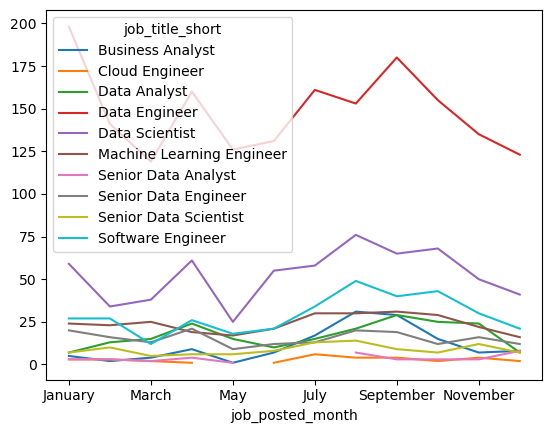

In [15]:
#plot the line graph
df_ru_pivot.plot(kind='line')

In [17]:
#let us focus on the top 5 roles
top_5 = df_ru['job_title_short'].value_counts().head(5)
top_5 = top_5.index.tolist()
top_5

['Data Engineer',
 'Data Scientist',
 'Software Engineer',
 'Machine Learning Engineer',
 'Data Analyst']

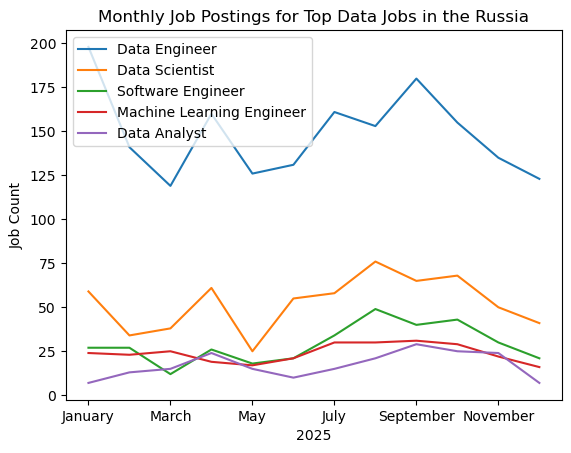

In [ ]:
#plotting only for the 5
#put a title and improve the labels on the plot
df_ru_pivot[top_5].plot(kind='line')
plt.title('Monthly Job Postings for Top Data Jobs in the Russia')
plt.xlabel('2025')
plt.ylabel('Job Count')
plt.legend()
plt.show()